In [65]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [66]:
import sys
import os

sys.path.append(os.path.abspath('../'))

from tagging_system import automate_tagging as auto_tag
from models.custom_classifier import CustomClassifier

In [67]:
import numpy as np
import pandas as pd

In [68]:
books = pd.read_csv('../data/data_with_author_and_awards.csv',
dtype = {
    'isbn' : 'str', # do this explicitly to avoide getting a warning by the interpreter
    'author_birthyear' : 'Int64', # we have to explicitly do this to avoid pandas implicitly casting as float
    'title_id' : 'Int64'
},
)
books = books.dropna() # we drop the books without descriptions because these are very, very unlikely to be winners any

In [69]:
tags = auto_tag.load_tags()
transformer = auto_tag.load_transformer()
tags_encoded = auto_tag.encode_tags()
tags_map = auto_tag.tag_dictionary()

In [70]:
books = auto_tag.encode_books(books, transformer) # takes a while

In [109]:
books = auto_tag.tag_books(books, transformer, tags_encoded)

In [110]:
books['target'] = books.hugo | books.locus
books['num_prev_awards'] = books.Hugo_Awards_Previously + books.Locus_Awards_Previously

books

,title_id,title,author,release_year,release_date,first_publisher,author_birthyear,author_birthplace,isbn,book_synopsis,tags,hugo,locus,month_of_publication,Author_Age_at_Publication,Hugo_Awards_Previously,Locus_Awards_Previously,Hugo_Nominee_Before,Locus_Nominee_Before,author_birthplace_country,author_birthplace_continent,encoded_synopsis,target,num_prev_awards,auto_tags
0,9372,The Long Loud Silence,Wilson Tucker,1954,1954-00-00,Dell,1914,"Deer Creek, Illinois, USA",0899683754,Publisher's description: Tomorrow's war -- the...,"['Anatomy of Wonder 1 Core Collection', 'biolo...",False,False,Unknown,40,0,0,False,False,USA,Central/North America,"[-0.041223828, 0.12155522, -0.006339091, 0.019...",False,0,"[0.08290264, 0.14734189, 0.12431235, 0.1894502..."
4,1908,The Forgotten Planet,Murray Leinster,1954,1954-00-00,Ace Books,1896,"Norfolk, Virginia, USA",0881846163,"**From the first page of the Ace Double:** ""Na...","['insects', 'Librivox', 'Project Gutenberg', '...",False,False,Unknown,58,0,0,False,False,USA,Central/North America,"[-0.025720153, 0.054792713, -0.021301318, 0.03...",False,0,"[0.16157854, 0.15408087, 0.13892937, 0.2267200..."
9,6101,The Star Beast,Robert A. Heinlein,1954,1954-08-23,Ace Books,1907,"Butler, Missouri, USA",0345275802,A talking alien pet has grown to the size of a...,"['aliens', 'diplomacy', 'Earth', 'first contac...",False,False,08,47,0,0,False,False,USA,Central/North America,"[-0.03175946, 0.06456888, 0.05577806, -0.02333...",False,0,"[0.0798375, 0.4434734, 0.16306816, 0.15915263,..."
11,1066774,The Wheels of Chance,H. G. Wells,1954,1954-00-00,J. M. Dent,1866,"Bromley, Kent, England, UK",0460019147,The comical Wheels of Chance was written in 18...,"['Classics', 'Adventure', 'Fiction', 'Science ...",False,False,Unknown,88,0,0,False,False,UK,Europe,"[-0.0009298305, 0.06744729, 0.03826583, 0.0196...",False,0,"[0.019181669, -0.010794001, 0.026794693, 0.263..."
17,2266,The Caves of Steel,Isaac Asimov,1954,1954-00-00,HarperCollins (UK),1920,"Petrovichi, Smolensk Governorate, Russia",0586008357,"""A Del Rey book."" It was bad enough when Lije ...","['agoraphobia', 'android', 'androids', 'arcolo...",False,False,Unknown,34,0,0,False,False,Russia,Europe,"[-0.11344511, 0.007374352, 0.012599569, 0.0339...",False,0,"[0.17593378, 0.26259395, 0.14352137, 0.1884754..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151563,3506858,Falling in a Sea of Stars,Kristen Britain,2025,2025-09-30,DAW Books,1965,"Batavia, New York, USA",9780756408824.0,"Magic, danger, and adventure abound for messen...","['Fiction', 'Fantasy', 'Adventure', 'War']",False,False,09,60,0,0,False,False,USA,Central/North America,"[-0.04759283, -0.034522656, -0.027196748, -0.0...",False,0,"[0.20009893, 0.06821477, 0.24174696, 0.1531779..."
151566,3506902,Lover Forbidden,J. R. Ward,2025,2025-09-09,Gallery Books,1969,"Boston, Massachusetts, USA",9781982179960.0,The aristocracy is making a run for the throne...,"['Fantasy', 'Fiction']",False,False,09,56,0,0,False,False,USA,Central/North America,"[-0.08131112, -0.051669966, -0.076406844, 0.01...",False,0,"[0.17815948, 0.030958246, 0.2653829, 0.2006627..."
151571,3507118,Fiend,Alma Katsu,2025,2025-09-16,G. P. Putnam's Sons,1959,"Fairbanks, Alaska, USA",9780593714348.0,"When Maris Berisha was nine years old, she hea...","['horror', 'Fiction', 'Fantasy', 'A mix driven...",False,False,09,66,0,0,False,False,USA,Central/North America,"[-0.044818047, 0.0097757345, 0.014525753, 0.02...",False,0,"[0.16496915, 0.054141305, 0.18310153, 0.258782..."
151579,3507075,Tiger's Trek,Colleen Houck,2025,2025-09-09,Blackstone Publishing,1969,"Tucson, Arizona, USA",9798212221733.0,From New York Times bestselling author Colleen...,"['Young Adult Fiction', 'Fantasy']",False,False,09,56,0,0,False,False,USA,Central/North America,"[-0.041875966, -0.0069684396, 0.012509349, 0.1...",False,0,"[0.13657653, 0.13215426, 0.20971912, 0.1531619..."


In [111]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score

In [166]:
# manually train test split our data

books_train = books[(books.release_year <= 2014) & (books.release_year >= 1971)]
books_test = books[books.release_year >= 2014]

books_tt = books_train[books_train.release_year <= 2005]
books_val = books_train[books_train.release_year > 2005]

In [171]:
books_tt.head()

,title_id,title,author,release_year,release_date,first_publisher,author_birthyear,author_birthplace,isbn,book_synopsis,tags,hugo,locus,month_of_publication,Author_Age_at_Publication,Hugo_Awards_Previously,Locus_Awards_Previously,Hugo_Nominee_Before,Locus_Nominee_Before,author_birthplace_country,author_birthplace_continent,encoded_synopsis,target,num_prev_awards,auto_tags
4548,2009247,The Hawkstone,Jay Williams,1971,1971-10-01,"Henry Z. Walck, Inc.",1914,"Buffalo, New York, USA",0809830965,"""A young New Englander is unaware of the stran...",[],False,False,10,57,0,0,False,False,USA,Central/North America,"[-0.036100663, 0.10305314, 0.032459974, 0.0384...",False,0,"[0.067467615, 0.17843407, 0.1643354, 0.0829386..."
4552,1997735,The Seal-Singing,Rosemary Harris,1971,1971-00-00,Faber and Faber,1923,"London, England, UK",0571096395,"""While spending the summer on a Scottish islan...",['selkies'],False,False,Unknown,48,0,0,False,False,UK,Europe,"[-0.07222478, 0.048827797, -0.00031475644, 0.0...",False,0,"[0.033640712, 0.09288115, 0.16777664, 0.185533..."
4553,449,Exiled from Earth,Ben Bova,1971,1971-04-00,Berkley Books,1932,"Philadelphia, Pennsylvania, USA",0425045250,3 science fiction-romaner.\n\n,"['Anatomy of Wonder 1 Core Collection', 'scien...",False,False,04,39,0,0,False,False,USA,Central/North America,"[-0.08211492, -0.05334223, -0.0065231794, 0.01...",False,0,"[0.18191844, 0.43575853, 0.36420703, 0.2395648..."
4557,13636,The Exorcist,William Peter Blatty,1971,1971-00-00,HarperPaperbacks,1928,"New York City, New York, USA",0061007226,The Exorcist is a 1971 horror novel by America...,"['Catholic exorcism', 'demon', 'horror', 'Horr...",False,False,Unknown,43,0,0,False,False,USA,Central/North America,"[-0.0025305643, 0.010534443, -0.02623904, 0.05...",False,0,"[-0.041045304, 0.030649167, 0.29221755, 0.1870..."
4561,13885,The Vampire Curse,Daoma Winston,1971,1971-00-00,Severn House,1922,"Washington, District of Columbia, USA",0727844490,Teena Halliday had heard rumours that Jeremy R...,['horror'],False,False,Unknown,49,0,0,False,False,USA,Central/North America,"[-0.027311608, 0.05795092, 0.008173795, 0.0292...",False,0,"[0.03277777, 0.13793644, 0.17406115, 0.1104987..."


In [172]:
#features = ['num_prev_awards', 'encoded_synopsis', 'first_publisher', 'author_birthplace_country', 'Author_Age_at_Publication']
features = ['num_prev_awards', 'encoded_synopsis', 'first_publisher', 'author_birthplace_country', 'Author_Age_at_Publication', 'auto_tags']

In [173]:
X_tt = books_train[features]
y_tt = books_train['target']

X_val = books_val[features]
y_val = books_val['target']

In [174]:
my_classifier = CustomClassifier(n_neighbors = 2, weights='distance', n_jobs = -1, class_weight='balanced')

my_classifier.fit(X_tt, y_tt)

In [175]:
pred = my_classifier.predict(X_val)
print('f1', f1_score(y_val, pred))
print('precision', precision_score(y_val, pred))

f1 0.99812382739212
precision 1.0


These are some suspiciously good metrics...

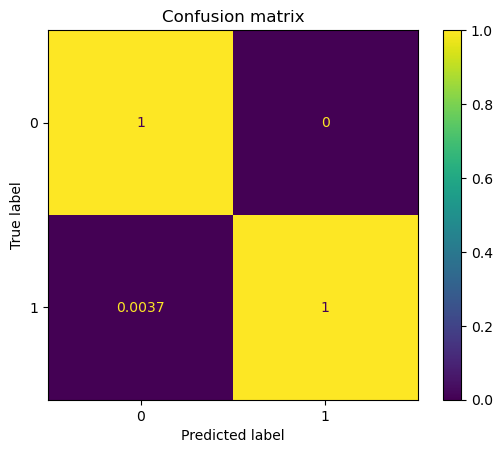

In [176]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, pred, normalize='true')
ConfusionMatrixDisplay(cm).plot()
plt.title('Confusion matrix')
plt.show()

These are some incredibly suspicious looking numbers. We should cross-validate to actually check.

In [135]:
tt_cv = [ books_train[(1971 <= books_train.release_year) & (books_train.release_year <= 1977)] ]
val_cv = [ books_train[(1978 <= books_train.release_year) & (books_train.release_year <= 1979)] ]

tt_cv.append( books_train[(1971 <= books_train.release_year) & (books_train.release_year <= 1985)] )
val_cv.append( books_train[(1986 <= books_train.release_year) & (books_train.release_year <= 1987)] )

tt_cv.append( books_train[(1971 <= books_train.release_year) & (books_train.release_year <= 1993)] )
val_cv.append( books_train[(1994 <= books_train.release_year) & (books_train.release_year <= 1995)] )

tt_cv.append( books_train[(1971 <= books_train.release_year) & (books_train.release_year <= 2001)] )
val_cv.append( books_train[(2002 <= books_train.release_year) & (books_train.release_year <= 2003)] )

tt_cv.append( books_train[(1971 <= books_train.release_year) & (books_train.release_year <= 2011)] )
val_cv.append( books_train[(2012 <= books_train.release_year) & (books_train.release_year <= 2014)] )

In [142]:
f1s = dict()
precs = dict()

my_classifier = CustomClassifier(n_neighbors = 2, weights='distance', n_jobs = -1, class_weight='balanced')

for i in range(5):
    X_tt_cv = tt_cv[i][features]
    y_tt_cv = tt_cv[i].target

    X_ho = val_cv[i][features]
    y_ho = val_cv[i].target

    my_classifier.fit(X_tt_cv, y_tt_cv)

    pred = my_classifier.predict(X_ho)

    f1s['Fold {} F_1'.format(i)] = f1_score(y_ho, pred)
    precs['Fold {} Precision'.format(i)] = precision_score(y_ho, pred)
    

In [137]:
avg = 0
for key in f1s:
    print(key, f1s[key], sep=": ")
    avg += f1s[key]
avg = avg / 5
print(avg)


Fold 0 F_1: 0.21621621621621623
Fold 1 F_1: 0.2222222222222222
Fold 2 F_1: 0.20689655172413793
Fold 3 F_1: 0.16455696202531644
Fold 4 F_1: 0.16342412451361868
0.1946632153403023


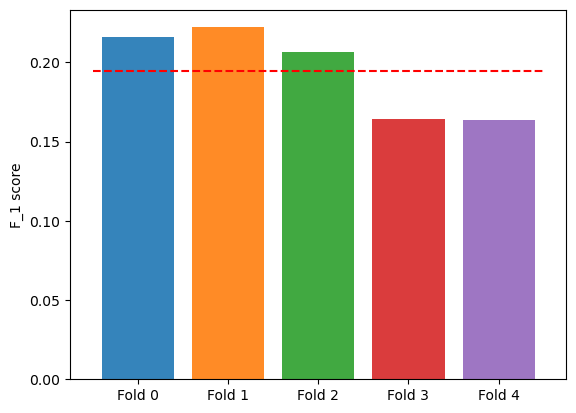

In [143]:
for key in f1s:
    plt.bar(x = 'Fold {}'.format(key.split(' ')[1]), height = f1s[key], alpha = 0.9)

plt.plot([-.5,4.5], [avg] * 2, linestyle='dashed', color='red')
plt.ylabel('F_1 score')
plt.show()

In [91]:
avg = 0
for key in precs:
    print(key, precs[key], sep=": ")
    avg += precs[key]
avg = avg / 5
print(avg)

Fold 0 Precision: 0.22857142857142856
Fold 1 Precision: 0.20588235294117646
Fold 2 Precision: 0.1836734693877551
Fold 3 Precision: 0.1320754716981132
Fold 4 Precision: 0.14102564102564102
0.17824567272482286


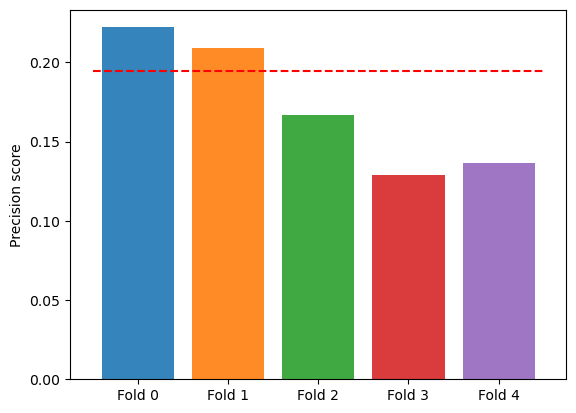

In [144]:
for key in precs:
    plt.bar(x = "Fold {}".format(key.split(' ')[1]), height = precs[key], alpha = 0.9)

plt.plot([-.5,4.5], [avg] * 2, linestyle='dashed', color='red')
plt.ylabel('Precision score')

plt.show()

As expected, we get much lower scores when we do cross-validation. This makes me wonder what was happening when we did the fitting on books_tt to get such ridiculously high scores.

In [98]:
from models.custom_classifier import CustomBaggingClassifier

n_ests = [2, 5, 10, 100, 200, 500]

avg_f1s = dict()
avg_precs = dict()

kwargs = {'n_neighbors' : 2, 'weights' : 'distance', 'n_jobs' : -1, 'class_weight' :'balanced'}


for n in n_ests:
    avg_f1 = 0
    avg_prec = 0
    bag = CustomBaggingClassifier(
            base_estimator = CustomClassifier,
            n_estimators = n,
            kwargs = kwargs
        )
    for i in range(5):

        X_tt_cv = tt_cv[i][features]
        y_tt_cv = tt_cv[i].target

        X_ho = val_cv[i][features]
        y_ho = val_cv[i].target

        bag.fit(X_tt_cv, y_tt_cv)
        pred = bag.predict(X_ho)

        avg_f1 += f1_score(y_ho, pred)
        avg_prec += precision_score(y_ho, pred)

    avg_f1s['{} estimators'.format(n)] = avg_f1 / 5
    avg_precs['{} estimators'.format(n)] = avg_prec / 5

In [99]:
avg_f1s

{'2 estimators': 0.17057567541088267,
 '5 estimators': 0.21483669161946461,
 '10 estimators': 0.1845284523699092,
 '100 estimators': 0.20386713077698587,
 '200 estimators': 0.2036811077215957,
 '500 estimators': 0.20337151019837588}

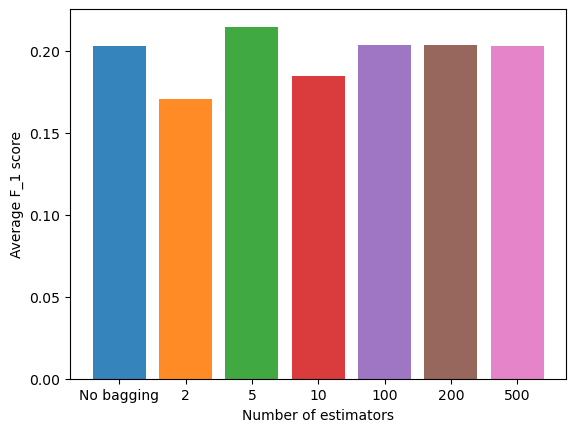

In [107]:
plt.bar(x = 'No bagging', height = 0.2033215903544372, alpha = 0.9)

for key in avg_f1s:
    plt.bar(x = key.split(' ')[0], height = avg_f1s[key], alpha=0.9)

plt.xlabel('Number of estimators')
plt.ylabel('Average F_1 score')

plt.show()

In [100]:
avg_precs

{'2 estimators': 0.20918946301925026,
 '5 estimators': 0.19898860310966465,
 '10 estimators': 0.1778367740411361,
 '100 estimators': 0.17972903815528923,
 '200 estimators': 0.1795206933365745,
 '500 estimators': 0.17914198515226984}

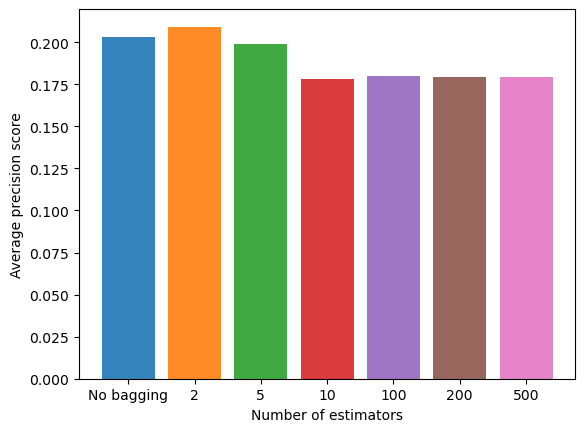

In [108]:
plt.bar(x = 'No bagging', height = 0.2033215903544372, alpha = 0.9)

for key in avg_precs:
    plt.bar(x = key.split(' ')[0], height = avg_precs[key], alpha=0.9)


plt.xlabel('Number of estimators')
plt.ylabel('Average precision score')

plt.show()

It seems on this sample, bagging with 5 estimators seem to do the best in terms of both $F_1$ and precision, but really bagging does not do much of anything.

In [205]:
from models.walkforward_cv import walk_forward


splits = walk_forward(books_train, step=4)

In [161]:
features

['num_prev_awards',
 'encoded_synopsis',
 'first_publisher',
 'author_birthplace_country',
 'Author_Age_at_Publication',
 'auto_tags']

In [154]:
splits[0][0].head()

,title_id,title,author,release_year,release_date,first_publisher,author_birthyear,author_birthplace,isbn,book_synopsis,tags,hugo,locus,month_of_publication,Author_Age_at_Publication,Hugo_Awards_Previously,Locus_Awards_Previously,Hugo_Nominee_Before,Locus_Nominee_Before,author_birthplace_country,author_birthplace_continent,encoded_synopsis,target,num_prev_awards,auto_tags
0,9372,The Long Loud Silence,Wilson Tucker,1954,1954-00-00,Dell,1914,"Deer Creek, Illinois, USA",0899683754,Publisher's description: Tomorrow's war -- the...,"['Anatomy of Wonder 1 Core Collection', 'biolo...",False,False,Unknown,40,0,0,False,False,USA,Central/North America,"[-0.041223828, 0.12155522, -0.006339091, 0.019...",False,0,"[0.08290264, 0.14734189, 0.12431235, 0.1894502..."
4,1908,The Forgotten Planet,Murray Leinster,1954,1954-00-00,Ace Books,1896,"Norfolk, Virginia, USA",0881846163,"**From the first page of the Ace Double:** ""Na...","['insects', 'Librivox', 'Project Gutenberg', '...",False,False,Unknown,58,0,0,False,False,USA,Central/North America,"[-0.025720153, 0.054792713, -0.021301318, 0.03...",False,0,"[0.16157854, 0.15408087, 0.13892937, 0.2267200..."
9,6101,The Star Beast,Robert A. Heinlein,1954,1954-08-23,Ace Books,1907,"Butler, Missouri, USA",0345275802,A talking alien pet has grown to the size of a...,"['aliens', 'diplomacy', 'Earth', 'first contac...",False,False,08,47,0,0,False,False,USA,Central/North America,"[-0.03175946, 0.06456888, 0.05577806, -0.02333...",False,0,"[0.0798375, 0.4434734, 0.16306816, 0.15915263,..."
11,1066774,The Wheels of Chance,H. G. Wells,1954,1954-00-00,J. M. Dent,1866,"Bromley, Kent, England, UK",0460019147,The comical Wheels of Chance was written in 18...,"['Classics', 'Adventure', 'Fiction', 'Science ...",False,False,Unknown,88,0,0,False,False,UK,Europe,"[-0.0009298305, 0.06744729, 0.03826583, 0.0196...",False,0,"[0.019181669, -0.010794001, 0.026794693, 0.263..."
17,2266,The Caves of Steel,Isaac Asimov,1954,1954-00-00,HarperCollins (UK),1920,"Petrovichi, Smolensk Governorate, Russia",0586008357,"""A Del Rey book."" It was bad enough when Lije ...","['agoraphobia', 'android', 'androids', 'arcolo...",False,False,Unknown,34,0,0,False,False,Russia,Europe,"[-0.11344511, 0.007374352, 0.012599569, 0.0339...",False,0,"[0.17593378, 0.26259395, 0.14352137, 0.1884754..."


In [206]:
my_classifier = CustomClassifier(n_neighbors = 2, weights='distance', n_jobs = -1, class_weight='balanced')


val_years = []
f1s = []
precs = []

for fold in splits:
    walk = fold[0]
    val = fold[1]
    
    X_tt = walk[features]
    y_tt = walk.target

    X_val = val[features]
    y_val = val.target

    my_classifier.fit(X_tt, y_tt)
    pred = my_classifier.predict(X_val)

    year = val.release_year.iloc[0]
    val_years.append(year)

    f1s.append(f1_score(y_val, pred))
    precs.append(precision_score(y_val, pred))
    

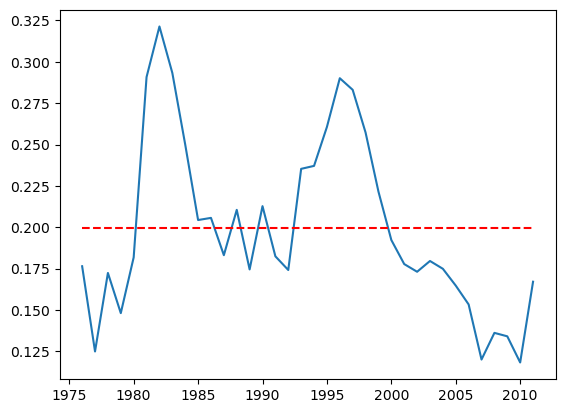

In [207]:
plt.plot(val_years, f1s)
avg_f1 = np.mean(f1s)
plt.plot([val_years[0], val_years[-1]], [avg_f1] * 2, color='red', linestyle='dashed')
plt.show()

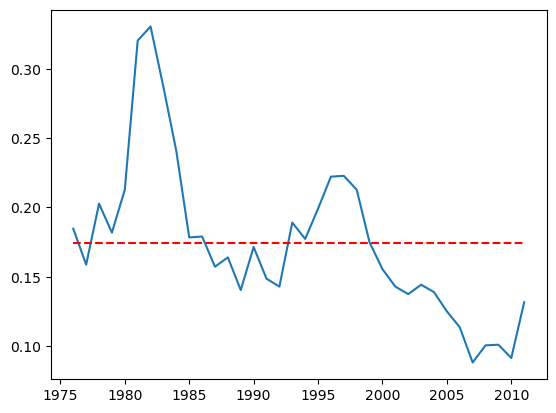

In [208]:
plt.plot(val_years, precs)
avg_prec = np.mean(precs)
plt.plot([val_years[0], val_years[-1]], [avg_prec] * 2, color='red', linestyle='dashed')
plt.show()